## Get the Data

Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange: 

Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get your own .csv file

<code>
select dateadd(month, datediff(month, 0, q.CreationDate), 0) m, TagName, count(*)
from PostTags pt
join Posts q on q.Id=pt.PostId
join Tags t on t.Id=pt.TagId
where TagName in ('java','c','c++','python','c#','javascript','assembly','php','perl','ruby','visual basic','swift','r','object-c','scratch','go','swift','delphi')
and q.CreationDate < dateadd(month, datediff(month, 0, getdate()), 0)
group by dateadd(month, datediff(month, 0, q.CreationDate), 0), TagName
order by dateadd(month, datediff(month, 0, q.CreationDate), 0)
</code>

## Import Statements

In [30]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from datetime import datetime

os.getcwd()

'/Users/acloudnerd/Desktop/acloudnerd/data-science/data-visualisation-basics/notebooks'

## Data Exploration

**Challenge**: Read the .csv file and store it in a Pandas dataframe

In [2]:
# read the data
data_path = "/Users/acloudnerd/Desktop/acloudnerd/data-science/data-visualisation-basics/data/prog_lang_data.csv"
data = pd.read_csv('../data/prog_lang_data.csv')

# rename the columns
data = data.rename(columns={'m' : 'DATE', 'TagName' : 'TAG', 'Unnamed: 2' : 'POSTS'})

**Challenge**: Examine the first 5 rows and the last 5 rows of the of the dataframe

In [8]:
df = pd.DataFrame(data)
first_five = df.head()
last_five = df.tail()
first_five

,DATE,TAG,POSTS
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,c,81
3,2008-08-01 00:00:00,c#,503
4,2008-08-01 00:00:00,c++,164


In [9]:
last_five

,DATE,TAG,POSTS
3008,2026-08-01 00:00:00,php,21
3009,2026-08-01 00:00:00,python,150
3010,2026-08-01 00:00:00,r,27
3011,2026-08-01 00:00:00,ruby,3
3012,2026-08-01 00:00:00,swift,19


**Challenge:** Check how many rows and how many columns there are. 
What are the dimensions of the dataframe?

In [4]:
# number of (rows, columns)
df.shape

(3013, 3)

**Challenge**: Count the number of entries in each column of the dataframe

In [10]:
# date_entries_count = df['DATE'].count()
# tag_entries_count = df['TAG'].count()
# post_entries_count = df['POSTS'].count()

# print(f"We have {date_entries_count} date entries, {tag_entries_count} tag entries, and {post_entries_count} post entries.")

df.count()

DATE     3013
TAG      3013
POSTS    3013
dtype: int64

**Challenge**: Calculate the total number of post per language.
Which Programming language has had the highest total number of posts of all time?

In [6]:
total_posts_per_language = df.groupby('TAG')['POSTS'].sum().sort_values(ascending=False)
total_posts_per_language

TAG
javascript    2521705
python        2204505
java          1914382
c#            1621715
php           1460900
c++            813981
r              510337
c              407965
swift          336108
ruby           229120
go              74457
perl            68295
delphi          52544
assembly        45073
Name: POSTS, dtype: int64

Some languages are older (e.g., C) and other languages are newer (e.g., Swift). The dataset starts in September 2008.

**Challenge**: How many months of data exist per language? Which language had the fewest months with an entry? 


In [ ]:
months_of_data_per_language = df.groupby('TAG').size().reset_index(name='size')
min_row = months_of_data_per_language.loc[months_of_data_per_language['size'].idxmin()]
print(min_row)
months_of_data_per_language

# df.groupby('TAG').count()

TAG      go
size    202
Name: 5, dtype: object


,TAG,size
0,assembly,217
1,c,217
2,c#,218
3,c++,217
4,delphi,217
5,go,202
6,java,217
7,javascript,217
8,perl,217
9,php,217


## Data Cleaning

Let's fix the date format to make it more readable. We need to use Pandas to change format from a string of "2008-07-01 00:00:00" to a datetime object with the format of "2008-07-01"

In [ ]:
# print(df.dtypes)
df['DATE'] = pd.to_datetime(df['DATE'])
df['DATE']

0      2008-07-01
1      2008-08-01
2      2008-08-01
3      2008-08-01
4      2008-08-01
          ...    
3008   2026-08-01
3009   2026-08-01
3010   2026-08-01
3011   2026-08-01
3012   2026-08-01
Name: DATE, Length: 3013, dtype: datetime64[us]

## Data Manipulation



In [ ]:
test_df = pd.DataFrame({'Age' : ['Young', 'Young', 'Young', 'Young', 'Old', 'Old', 'Old', 'Old'], 'Actor' : ['Jack', 'Arnold', 'Keanu', 'Sylvester', 'Jack', 'Arnold', 'Keanu', 'Sylvester'], 'Power' : [100, 80, 25, 50, 99, 75, 5, 30]})
test_df

,Age,Actor,Power
0,Young,Jack,100
1,Young,Arnold,80
2,Young,Keanu,25
3,Young,Sylvester,50
4,Old,Jack,99
5,Old,Arnold,75
6,Old,Keanu,5
7,Old,Sylvester,30


In [18]:
pivoted_df = test_df.pivot(index='Age', columns='Actor', values='Power')
pivoted_df

Actor,Arnold,Jack,Keanu,Sylvester
Age,,,,
Old,75,99,5,30
Young,80,100,25,50


**Challenge**: What are the dimensions of our new dataframe? How many rows and columns does it have? Print out the column names and print out the first 5 rows of the dataframe.

In [19]:
reshaped_df = df.pivot(index='DATE', columns='TAG', values='POSTS')
reshaped_df

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,8.0,81.0,503.0,164.0,13.0,NaN,220.0,160.0,28.0,157.0,119.0,NaN,68.0,NaN
2008-09-01,28.0,320.0,1636.0,749.0,104.0,NaN,1119.0,629.0,128.0,471.0,533.0,6.0,285.0,NaN
2008-10-01,16.0,302.0,1982.0,804.0,112.0,NaN,1142.0,721.0,128.0,603.0,504.0,NaN,245.0,NaN
2008-11-01,16.0,257.0,1727.0,733.0,139.0,NaN,951.0,581.0,97.0,497.0,446.0,1.0,154.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-01,18.0,81.0,136.0,130.0,7.0,9.0,139.0,151.0,8.0,45.0,286.0,94.0,2.0,40.0
2026-05-01,17.0,62.0,108.0,135.0,4.0,9.0,152.0,135.0,6.0,51.0,243.0,48.0,2.0,39.0
2026-06-01,8.0,65.0,100.0,102.0,11.0,6.0,85.0,99.0,6.0,29.0,222.0,42.0,2.0,31.0


In [21]:
reshaped_df.columns

Index(['assembly', 'c', 'c#', 'c++', 'delphi', 'go', 'java', 'javascript',
       'perl', 'php', 'python', 'r', 'ruby', 'swift'],
      dtype='str', name='TAG')

**Challenge**: Count the number of entries per programming language. Why might the number of entries be different? 

In [24]:
reshaped_df.count()

TAG
assembly      217
c             217
c#            218
c++           217
delphi        217
go            202
java          217
javascript    217
perl          217
php           217
python        217
r             215
ruby          217
swift         208
dtype: int64

In [25]:
reshaped_df.fillna(0, inplace=True)

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-08-01,8.0,81.0,503.0,164.0,13.0,0.0,220.0,160.0,28.0,157.0,119.0,0.0,68.0,0.0
2008-09-01,28.0,320.0,1636.0,749.0,104.0,0.0,1119.0,629.0,128.0,471.0,533.0,6.0,285.0,0.0
2008-10-01,16.0,302.0,1982.0,804.0,112.0,0.0,1142.0,721.0,128.0,603.0,504.0,0.0,245.0,0.0
2008-11-01,16.0,257.0,1727.0,733.0,139.0,0.0,951.0,581.0,97.0,497.0,446.0,1.0,154.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-01,18.0,81.0,136.0,130.0,7.0,9.0,139.0,151.0,8.0,45.0,286.0,94.0,2.0,40.0
2026-05-01,17.0,62.0,108.0,135.0,4.0,9.0,152.0,135.0,6.0,51.0,243.0,48.0,2.0,39.0
2026-06-01,8.0,65.0,100.0,102.0,11.0,6.0,85.0,99.0,6.0,29.0,222.0,42.0,2.0,31.0


In [28]:
reshaped_df.isna().values.any()

np.False_

## Data Visualisaton with with Matplotlib


**Challenge**: Use the [matplotlib documentation](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot) to plot a single programming language (e.g., java) on a chart.

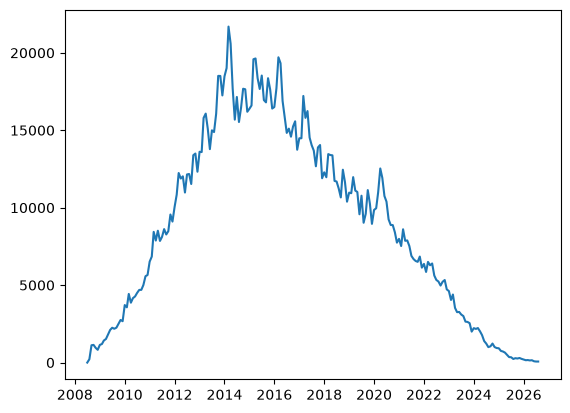

In [34]:
plt.plot(reshaped_df.index, reshaped_df['java'])

**Challenge**: Show two line (e.g. for Java and Python) on the same chart.

# Smoothing out Time Series Data

Time series data can be quite noisy, with a lot of up and down spikes. To better see a trend we can plot an average of, say 6 or 12 observations. This is called the rolling mean. We calculate the average in a window of time and move it forward by one overservation. Pandas has two handy methods already built in to work this out: [rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) and [mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.window.rolling.Rolling.mean.html). 